In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('WBD','GS'), 
         ('WBD','CAT'), 
         ('WBD','MSFT'), 
         ('ALB','GS'), 
         ('ALB', 'CAT'),
         ('ALB', 'MSFT'), 
         ('WDC','GS'), 
         ('WDC', 'CAT'), 
         ('WDC','MSFT')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, 

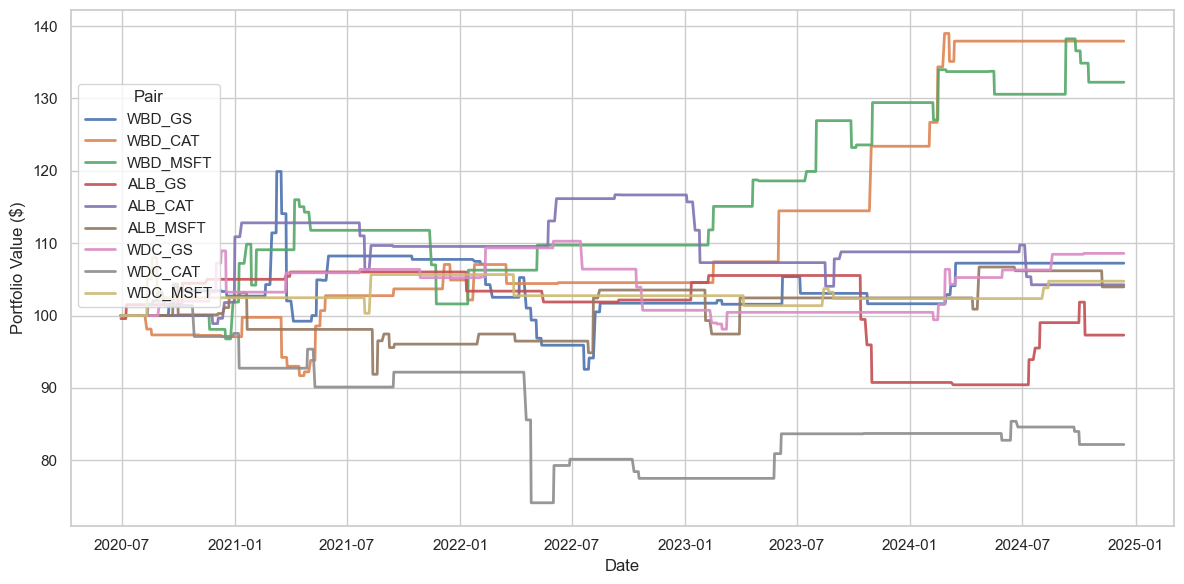

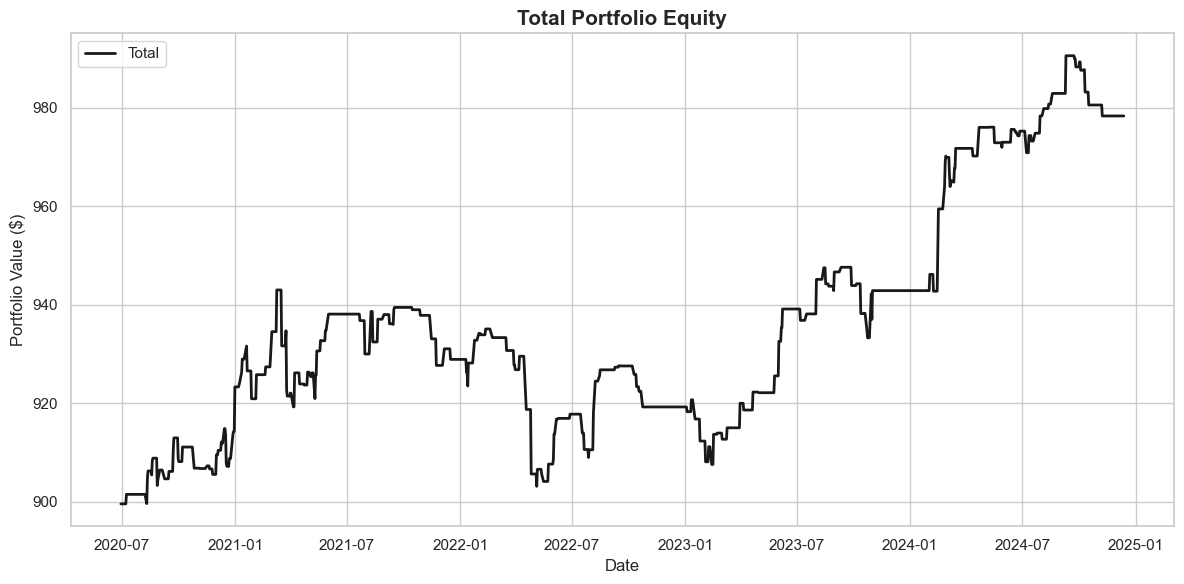

Summary
WBD_GS: Final Value = $107.23, Total Return = 7.23%, Trades = 37
WBD_CAT: Final Value = $137.91, Total Return = 37.91%, Trades = 28
WBD_MSFT: Final Value = $132.23, Total Return = 32.23%, Trades = 33
ALB_GS: Final Value = $97.29, Total Return = -2.29%, Trades = 20
ALB_CAT: Final Value = $104.25, Total Return = 4.25%, Trades = 23
ALB_MSFT: Final Value = $103.95, Total Return = 3.95%, Trades = 24
WDC_GS: Final Value = $108.59, Total Return = 8.59%, Trades = 26
WDC_CAT: Final Value = $82.18, Total Return = -17.82%, Trades = 24
WDC_MSFT: Final Value = $104.74, Total Return = 4.74%, Trades = 12

Total Portfolio Performance
Initial Portfolio Value: $899.57
Final Portfolio Value:   $978.38
Total Return:            8.76%

Sharpe Ratios
WBD_GS: Sharpe Ratio = 0.21
WBD_CAT: Sharpe Ratio = 0.90
WBD_MSFT: Sharpe Ratio = 0.70
ALB_GS: Sharpe Ratio = -0.06
ALB_CAT: Sharpe Ratio = 0.17
ALB_MSFT: Sharpe Ratio = 0.15
WDC_GS: Sharpe Ratio = 0.35
WDC_CAT: Sharpe Ratio = -0.40
WDC_MSFT: Sharpe Rati

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)